# Plots y visualizacion de los datos

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
import numpy as np

In [22]:
mainpath = r"C:\Users\USER\OneDrive\Documentos\GitHub\python-ml-course"
filename = "datasets\customer-churn-model\Customer Churn Model.txt"
fullpath = os.path.join(mainpath,filename)
data = pd.read_csv(fullpath)
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


Data ya cargada

% matplotlib inline
Esto lo que hace es evitar que se abra una ventana adicional al momento de ejecutar un grafico, por lo que el grafico que incrustado en el notebook

### Scatter plots

<Axes: xlabel='Day Mins', ylabel='Day Charge'>

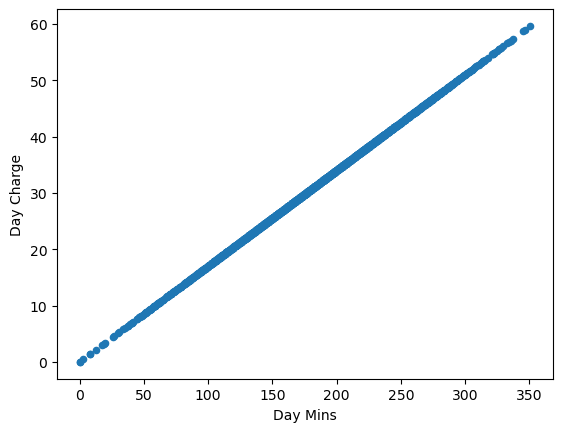

In [19]:
# Hacer el ejercicio con datos de dia
data.plot(kind="scatter", x = "Day Mins", y = "Day Charge")

<Axes: xlabel='Night Mins', ylabel='Night Charge'>

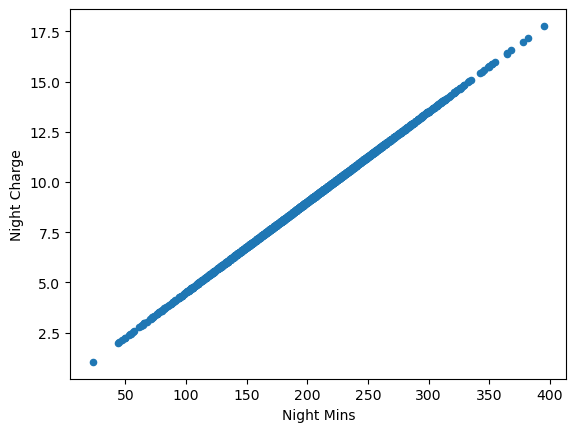

In [23]:
# Hacer el mismo ejercicio, pero esta vez con datos de noche
data.plot(kind = "scatter",x = "Night Mins", y = "Night Charge")

<Axes: xlabel='Night Calls', ylabel='Night Charge'>

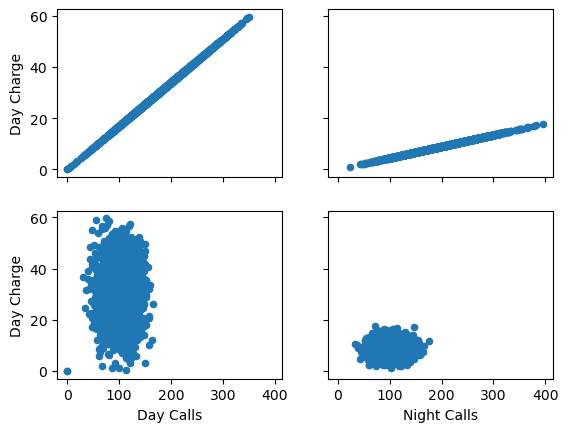

In [35]:
figure, axs = plt.subplots(2,2, sharey = True, sharex=True )
data.plot(kind="scatter",x = "Day Mins",y = "Day Charge", ax = axs[0][0])
data.plot(kind="scatter",x = "Night Mins",y = "Night Charge", ax = axs[0][1])
data.plot(kind="scatter",x = "Day Calls",y = "Day Charge", ax = axs[1][0])
data.plot(kind="scatter",x = "Night Calls",y = "Night Charge", ax = axs[1][1])

### Histogramas de frecuencia

<Axes: ylabel='Frequency'>

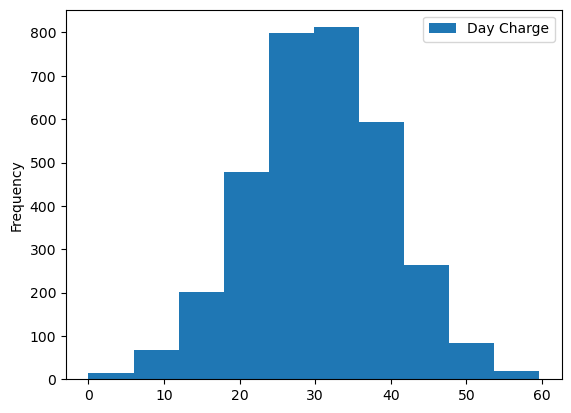

In [37]:
data.plot(kind="hist",x = "Day Calls",y = "Day Charge")

Text(0.5, 1.0, 'Histograma de numero de llamadas al dia')

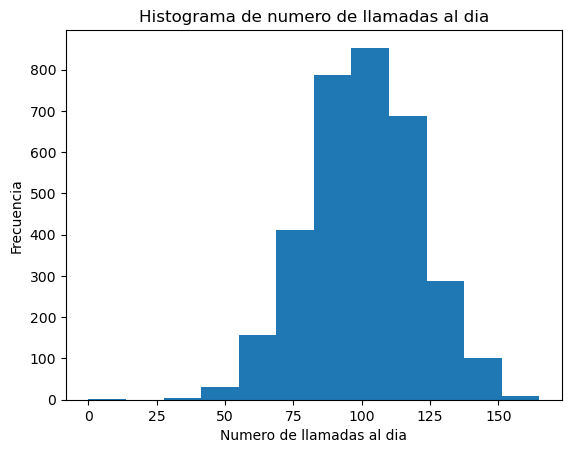

In [50]:
# Usando la libreria de plt
k = int(1 + np.log2(len(data))) # Aplicando regla de Sturger 1 + log2(#numero de muestras)
plt.hist(data["Day Calls"],bins = k)
plt.xlabel("Numero de llamadas al dia")
plt.ylabel("Frecuencia")
plt.title("Histograma de numero de llamadas al dia")
# Bins puede ser un array con diferentes valores, para determinar elvalor optimos se utiliza la regla de sturges

### Boxplot, diagrama de caja y bigotes

Text(0.5, 1.0, 'Numero de llamadas en el dia')

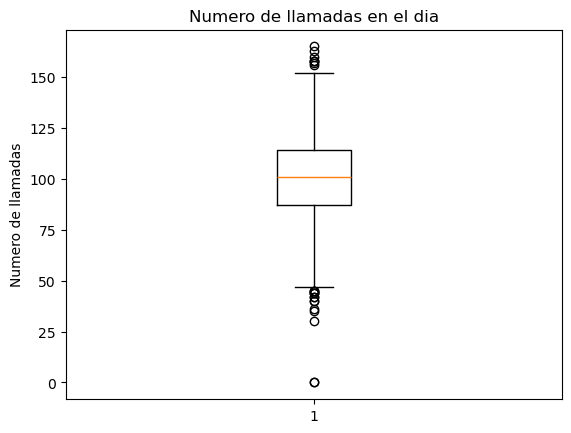

In [52]:
plt.boxplot(data["Day Calls"])
plt.ylabel("Numero de llamadas")
plt.title("Numero de llamadas en el dia")

In [53]:
data["Day Calls"].describe()

count    3333.000000
mean      100.435644
std        20.069084
min         0.000000
25%        87.000000
50%       101.000000
75%       114.000000
max       165.000000
Name: Day Calls, dtype: float64

In [60]:
IQR = data["Day Calls"].quantile(0.75)-data["Day Calls"].quantile(0.25)
int(IQR)

27

In [61]:
data["Day Calls"].quantile(0.25) - 1.5*IQR

np.float64(46.5)

In [62]:
data["Day Calls"].quantile(0.75) + 1.5*IQR

np.float64(154.5)

* Esto es muy util para saber cuales son los outliers
* Se utiliza mucho principalmente cuando hay variables categoricas para ser graficados uno al lado del otro